In [1]:
# ==========================================================
# Import required libraries
# ==========================================================

import sys
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt

from sklearn.decomposition import PCA

In [2]:
# ==========================================================
# Add project root to notebook path
# ==========================================================

project_root = Path("..").resolve()

if str(project_root) not in sys.path:
    sys.path.append(str(project_root))

print(project_root)

C:\Users\Lenovo\Desktop\meetscribe


In [3]:
# ==========================================================
# Import same modules used inside website
# ==========================================================

from ml_mom.transcript_parser import parse_transcript
from ml_mom.preprocessing import preprocess_transcript
from ml_mom.feature_extraction import extract_sentence_features
from ml_mom.embeddings import EmbeddingService
from ml_mom.clustering import ClusteringService

In [4]:
# ==========================================================
# Read transcript file
# ==========================================================

transcript_path = project_root / "datasets" / "raw_transcripts" / "meeting11.txt"

with open(transcript_path,"r",encoding="utf-8") as file:
    transcript = file.read()

print(transcript[:500])

Participants

Rohan (Client)
Simran (Business Analyst)
Kunal (Developer)
Sneha (UI Designer)

[11:00:08] Rohan: Good morning.

[11:00:20] Simran: Thanks everyone for joining.

[11:00:40] Rohan: We want users to receive meeting summaries automatically by email.

[11:01:05] Kunal: That's technically possible.

[11:01:25] Sneha: Should users be able to customize the email template?

[11:01:50] Rohan: Yes, customization would be useful.

[11:02:20] Simran: Should summaries also include action items?


In [5]:
# ==========================================================
# Run same ML pipeline as website
# ==========================================================

parsed = parse_transcript(transcript)

clean_turns = preprocess_transcript(parsed.turns)

sentence_features = extract_sentence_features(clean_turns)

embedding_service = EmbeddingService()

embedding_result = embedding_service.generate_embeddings(sentence_features)

embeddings = embedding_result.embeddings

print("Embeddings Generated :",len(embeddings))

c:\Users\Lenovo\Desktop\meetscribe\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
Loading weights: 100%|██████████| 103/103 [00:00<00:00, 4277.87it/s]


Embeddings Generated : 19


In [6]:
# ==========================================================
# Perform Agglomerative Clustering
# ==========================================================

clustering_service = ClusteringService()

clustering_result = clustering_service.cluster(embeddings)

print(clustering_result)

ClusteringResult(clusters=[SentenceCluster(cluster_id=0, topic_label="Email / I'Ll / Users", sentence_ids=[3, 5, 6, 7, 9, 10, 14, 15, 16], member_sentences=['We want users to receive meeting summaries automatically by email.', 'Should users be able to customize the email template?', 'Yes, customization would be useful.', 'Should summaries also include action items?', 'We can also attach the transcript as a PDF.', 'That would improve usability.', "I'll implement automatic email delivery.", "I'll design the email template.", "I'll prepare the requirement document."], centroid_embedding=[-0.05949662708573871, 0.026466132866011724, -0.013745915558603074, -0.004300588522002929, 0.02809865448054754, 0.024546900971068278, -0.02713058507975398, 0.004278046027239826, -0.011221261695027351, -0.005701678649832805, -0.027457846535576716, 0.06822249898687005, -0.031046774859229725, 0.031720048929047256, 0.025423012673854828, -0.0016358072559038799, 0.02852192459007104, 0.016722298227250576, 0.00402

In [7]:
# ==========================================================
# Convert embedding vectors into NumPy array
# ==========================================================

vectors = np.array([
    emb.embedding_vector
    for emb in embeddings
])

print(vectors.shape)

(19, 384)


In [8]:
# ==========================================================
# Reduce embeddings from 384D to 2D
# ==========================================================

pca = PCA(n_components=2)

points = pca.fit_transform(vectors)

print(points.shape)

(19, 2)


In [12]:
# ==========================================================
# Create cluster labels for every sentence.
#
# Every sentence receives the ID of the cluster
# it belongs to.
# ==========================================================

# Initially every sentence has cluster = -1
labels = np.full(len(sentence_features), -1)

# Visit every cluster
for cluster in clustering_result.clusters:

    # Visit every sentence inside that cluster
    for sentence_id in cluster.sentence_ids:

        # Assign cluster id to that sentence
        if sentence_id < len(labels):
            labels[sentence_id] = cluster.cluster_id

print(labels)

[-1  1  1  0  3  0  0  0  1  0  0  2  3  2  0  0  0  1  1]


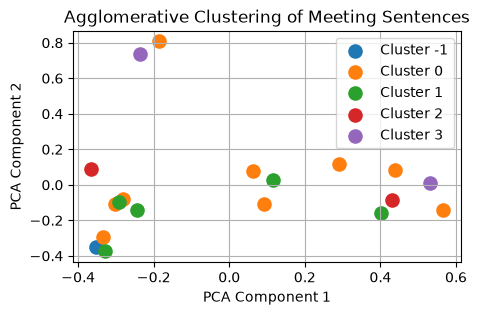

In [14]:
# ==========================================================
# Visualize clusters.
#
# Every colour represents one cluster.
# Similar sentences should appear close together.
# ==========================================================

plt.figure(figsize=(5,3))

unique_clusters = np.unique(labels)

for cluster in unique_clusters:

    mask = labels == cluster

    plt.scatter(
        points[mask,0],
        points[mask,1],
        s=90,
        label=f"Cluster {cluster}"
    )

plt.title("Agglomerative Clustering of Meeting Sentences")

plt.xlabel("PCA Component 1")

plt.ylabel("PCA Component 2")

plt.grid(True)

plt.legend()

plt.show()

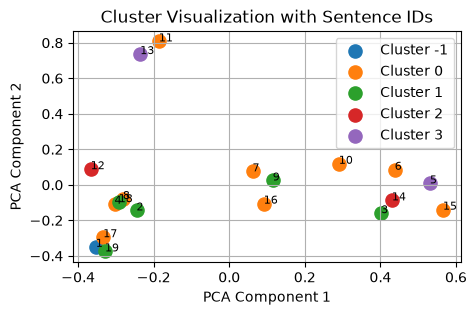

In [19]:
# ==========================================================
# Show sentence numbers on the graph.
#
# This helps identify which point belongs to
# which transcript sentence.
# ==========================================================

plt.figure(figsize=(5,3))

unique_clusters = np.unique(labels)

for cluster in unique_clusters:

    mask = labels == cluster

    plt.scatter(
        points[mask,0],
        points[mask,1],
        s=90,
        label=f"Cluster {cluster}"
    )

# Print sentence number over every point
for i in range(len(points)):

    plt.text(
        points[i,0],
        points[i,1],
        str(i+1),
        fontsize=8
    )

plt.title("Cluster Visualization with Sentence IDs")

plt.xlabel("PCA Component 1")

plt.ylabel("PCA Component 2")

plt.grid(True)

plt.legend()

plt.show()

In [17]:
# ==========================================================
# Print sentences present inside every cluster.
#
# This shows what topic each cluster represents.
# ==========================================================

for cluster in clustering_result.clusters:

    print("="*80)

    print(f"Cluster {cluster.cluster_id}")

    print(f"Topic Label : {cluster.topic_label}")

    print(f"Cluster Size : {cluster.cluster_size}")

    print()

    for sentence in cluster.member_sentences:

        print("•", sentence)

    print()

Cluster 0
Topic Label : Email / I'Ll / Users
Cluster Size : 9

• We want users to receive meeting summaries automatically by email.
• Should users be able to customize the email template?
• Yes, customization would be useful.
• Should summaries also include action items?
• We can also attach the transcript as a PDF.
• That would improve usability.
• I'll implement automatic email delivery.
• I'll design the email template.
• I'll prepare the requirement document.

Cluster 1
Topic Label : Good / Morning / Thanks
Cluster Size : 6

• Good morning.
• Thanks everyone for joining.
• Definitely.
• Perfect.
• Today's decisions are finalized.
• Meeting closed.

Cluster 2
Topic Label : Multilingual / Support / Need
Cluster Size : 2

• Do we need multilingual support?
• Okay, multilingual support will be moved to the next release.

Cluster 3
Topic Label : That'S / Technically / Possible
Cluster Size : 2

• That's technically possible.
• Not in Phase 1.



In [18]:
# ==========================================================
# Display cluster summary.
# ==========================================================

print("Total Clusters :", len(clustering_result.clusters))

print()

for cluster in clustering_result.clusters:

    print(f"Cluster {cluster.cluster_id}")

    print("Topic :", cluster.topic_label)

    print("Total Sentences :", cluster.cluster_size)

    print()

Total Clusters : 4

Cluster 0
Topic : Email / I'Ll / Users
Total Sentences : 9

Cluster 1
Topic : Good / Morning / Thanks
Total Sentences : 6

Cluster 2
Topic : Multilingual / Support / Need
Total Sentences : 2

Cluster 3
Topic : That'S / Technically / Possible
Total Sentences : 2

